# Project 1 — House Price Prediction

You are provided with a dataset containing information about houses and **prices**. The dataset is already split into `train.csv` and `test.csv`. The `data_description.txt` file contains descriptions of the columns.

**Goal:** Build models to predict house prices.

Please include detailed explanations of the following steps:

1. Data cleaning and preprocessing.
2. Model training and validation.
3. Model comparison based on regression metrics.

**Note:** You are **encouraged** to look for other machine learning algorithms online (beyond the course material), but you must study and understand these algorithms. You must not remove any rows from the `test.csv` file.

## 1. Exploratory data analysis and data-preparation handoff

This section covers the first team member's work: data integrity checks, missing-value analysis, target exploration, relationships between important features and price, and a clear preprocessing contract for the modeling team.

The raw CSV files are intentionally left unchanged. Imputation and encoding must later be fitted inside a scikit-learn `Pipeline`, using only the training folds, to avoid data leakage.

In [19]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-house-price")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

RANDOM_STATE = 42
ARTIFACT_DIR = Path("eda_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

### 1.1 Load the supplied data

`SalePrice` is the regression target. `Id` is an identifier, not a house characteristic, so it must be retained only for traceability and excluded from model features.

In [20]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
original_test_row_count = len(test)

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
display(train.head())

Train shape: (1314, 81)
Test shape:  (146, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1030,160,RM,21.000,1680,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrDale,Norm,Norm,Twnhs,2Story,6,7,1972,1972,Gable,CompShg,HdBoard,HdBoard,BrkFace,281.000,TA,TA,CBlock,TA,TA,No,BLQ,317,Unf,0,355,672,GasA,Gd,Y,SBrkr,672,546,0,1218,0,1,1,1,3,1,TA,7,Typ,0,NaN,Detchd,"1,972.000",Unf,1,264,TA,TA,Y,0,28,0,0,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal,118000
1,366,70,RM,59.000,10690,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,1Fam,2Story,5,7,1920,1997,Hip,CompShg,VinylSd,VinylSd,NaN,0.000,TA,Gd,CBlock,TA,Fa,No,Rec,456,Unf,0,216,672,GasA,Gd,Y,FuseA,672,672,0,1344,0,0,1,0,3,1,TA,6,Typ,0,NaN,Detchd,"1,964.000",Unf,1,468,TA,Fa,Y,0,128,218,0,0,0,NaN,NaN,NaN,0,7,2009,WD,Normal,147000
2,883,60,RL,NaN,9636,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1992,1993,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,808,808,GasA,Gd,Y,SBrkr,808,785,0,1593,0,0,2,1,3,1,TA,7,Typ,1,TA,BuiltIn,"1,993.000",RFn,2,389,TA,TA,Y,342,40,0,0,0,0,NaN,MnPrv,NaN,0,12,2009,WD,Normal,178000
3,94,190,C (all),60.000,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,OldTown,Norm,Norm,2fmCon,2.5Unf,6,6,1910,1998,Hip,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,BrkTil,TA,Fa,Mn,Rec,1046,Unf,0,168,1214,GasW,Ex,N,SBrkr,1260,1031,0,2291,0,1,2,0,4,2,TA,9,Typ,1,Gd,Detchd,"1,900.000",Unf,2,506,TA,TA,Y,0,0,0,0,99,0,NaN,NaN,NaN,0,11,2007,WD,Normal,133900
4,1360,20,RL,129.000,16737,Pave,NaN,Reg,Lvl,AllPub,FR3,Gtl,NridgHt,Norm,Norm,1Fam,1Story,9,5,2004,2005,Hip,CompShg,VinylSd,VinylSd,BrkFace,66.000,Gd,TA,PConc,Ex,TA,Av,GLQ,1447,Unf,0,533,1980,GasA,Ex,Y,SBrkr,1980,0,0,1980,1,0,2,0,3,1,Ex,8,Typ,1,Gd,Attchd,"2,004.000",Fin,3,770,TA,TA,Y,194,45,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Normal,315000


### 1.2 Integrity and split checks

The supplied `test.csv` unusually includes the true `SalePrice`. That column must be quarantined: it is not an input feature and should be used only once, after model selection, for the final unbiased evaluation. We do not inspect its distribution in this EDA.

In [21]:
required_columns = {"Id", "SalePrice"}
assert required_columns.issubset(train.columns)
assert required_columns.issubset(test.columns)
assert list(train.columns) == list(test.columns)
assert train["SalePrice"].notna().all()
assert test["SalePrice"].notna().all()

train_test_id_overlap = set(train["Id"]) & set(test["Id"])

dataset_overview = pd.DataFrame(
    {
        "rows": [len(train), len(test)],
        "columns": [train.shape[1], test.shape[1]],
        "duplicate_rows": [train.duplicated().sum(), test.duplicated().sum()],
        "duplicate_ids": [train["Id"].duplicated().sum(), test["Id"].duplicated().sum()],
        "missing_cells": [train.isna().sum().sum(), test.isna().sum().sum()],
    },
    index=["train", "test"],
)

display(dataset_overview)
print(f"Overlapping Id values between train and test: {len(train_test_id_overlap)}")

assert train.duplicated().sum() == 0
assert test.duplicated().sum() == 0
assert train["Id"].is_unique and test["Id"].is_unique
assert len(train_test_id_overlap) == 0

dataset_overview.to_csv(ARTIFACT_DIR / "dataset_overview.csv", index_label="dataset")

,rows,columns,duplicate_rows,duplicate_ids,missing_cells
train,1314,81,0,0,7072
test,146,81,0,0,757


Overlapping Id values between train and test: 0


### 1.3 Feature types

There are 79 candidate predictors after excluding `Id` and `SalePrice`. Although `MSSubClass` is stored as an integer, the data description defines its values as dwelling categories. The modeling pipeline should therefore cast it to a string/category before one-hot encoding.

In [22]:
feature_columns = [column for column in train.columns if column not in ["Id", "SalePrice"]]
numeric_features_raw = train[feature_columns].select_dtypes(include=np.number).columns.tolist()
categorical_features_raw = train[feature_columns].select_dtypes(exclude=np.number).columns.tolist()

feature_type_summary = pd.DataFrame(
    {
        "raw_feature_type": ["numeric", "categorical", "total"],
        "count": [len(numeric_features_raw), len(categorical_features_raw), len(feature_columns)],
    }
)
display(feature_type_summary)
print("Coded categorical feature currently stored as numeric: MSSubClass")

,raw_feature_type,count
0,numeric,36
1,categorical,43
2,total,79


Coded categorical feature currently stored as numeric: MSSubClass


### 1.4 Missing values

Missing values are not all the same. In many Ames Housing columns, a blank means that the house does not have that component (for example, no pool or no garage). Treating every blank as an unknown value would lose useful information.

In [23]:
missing_summary = pd.DataFrame(
    {
        "train_missing": train.isna().sum(),
        "train_missing_pct": train.isna().mean().mul(100),
        "test_missing": test.isna().sum(),
        "test_missing_pct": test.isna().mean().mul(100),
    }
)
missing_summary = missing_summary.loc[
    (missing_summary["train_missing"] > 0) | (missing_summary["test_missing"] > 0)
].sort_values("train_missing_pct", ascending=False)

display(missing_summary.round(2))
missing_summary.to_csv(ARTIFACT_DIR / "missing_values_summary.csv", index_label="feature")

,train_missing,train_missing_pct,test_missing,test_missing_pct
PoolQC,1307,99.470,146,100.000
MiscFeature,1266,96.350,140,95.890
Alley,1231,93.680,138,94.520
Fence,1068,81.280,111,76.030
MasVnrType,788,59.970,84,57.530
FireplaceQu,621,47.260,69,47.260
LotFrontage,236,17.960,23,15.750
GarageType,78,5.940,3,2.050
GarageYrBlt,78,5.940,3,2.050
GarageFinish,78,5.940,3,2.050


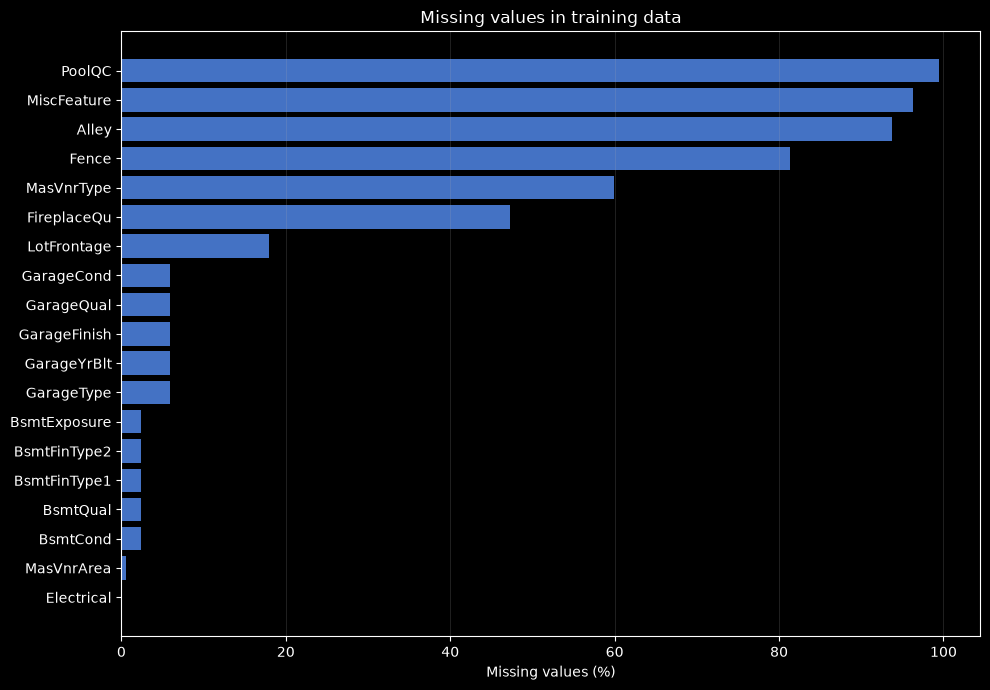

In [24]:
top_missing = missing_summary.head(20).sort_values("train_missing_pct")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_missing.index, top_missing["train_missing_pct"], color="#4472C4")
ax.set_title("Missing values in training data")
ax.set_xlabel("Missing values (%)")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "missing_values_train.png", dpi=160, bbox_inches="tight")
plt.show()

In [25]:
absence_means_none = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature",
]

numeric_absence_as_zero = ["MasVnrArea"]
numeric_missing_needs_imputation = ["LotFrontage", "GarageYrBlt"]
categorical_missing_needs_imputation = ["Electrical"]

missing_strategy = pd.DataFrame(
    {
        "group": [
            "Structural absence → 'None'",
            "Structural absence → 0",
            "Numeric unknown → median + optional missing indicator",
            "Categorical unknown → most frequent",
        ],
        "features": [
            ", ".join(absence_means_none),
            ", ".join(numeric_absence_as_zero),
            ", ".join(numeric_missing_needs_imputation),
            ", ".join(categorical_missing_needs_imputation),
        ],
    }
)
display(missing_strategy)

,group,features
0,Structural absence → 'None',"Alley, MasVnrType, BsmtQual, BsmtCond, BsmtExp..."
1,Structural absence → 0,MasVnrArea
2,Numeric unknown → median + optional missing in...,"LotFrontage, GarageYrBlt"
3,Categorical unknown → most frequent,Electrical


Recommended handling:

- fill structural-absence categories with an explicit value such as `"None"`;
- use `0` for `MasVnrArea` when `MasVnrType` indicates no veneer;
- impute genuinely unknown numeric values inside the pipeline, preferably with the training median and a missing indicator;
- impute `Electrical` with the most frequent training category;
- do not delete test rows, and avoid deleting training rows unless a later experiment provides a documented reason;
- fit every imputer and encoder only on training data or within each cross-validation fold.

### 1.5 Target distribution

House prices are positive and right-skewed. This matters because RMSE is sensitive to expensive outliers. The modeling team should report metrics in dollars on the original scale and may also compare a `log1p(SalePrice)` target transformation.

In [26]:
target_summary = train["SalePrice"].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).to_frame("SalePrice")
target_skew = train["SalePrice"].skew()

display(target_summary)
print(f"SalePrice skewness: {target_skew:.3f}")

,SalePrice
count,"1,314.000"
mean,"181,045.475"
std,"79,863.286"
min,"34,900.000"
1%,"61,179.790"
25%,"130,000.000"
50%,"162,950.000"
75%,"214,000.000"
99%,"445,447.070"
max,"755,000.000"


SalePrice skewness: 1.876


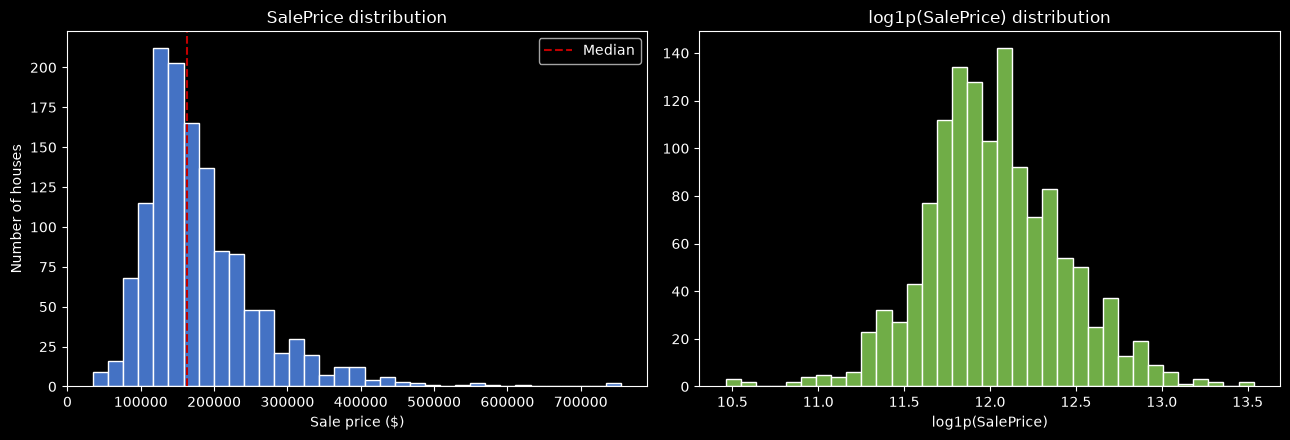

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(train["SalePrice"], bins=35, color="#4472C4", edgecolor="white")
axes[0].axvline(train["SalePrice"].median(), color="#C00000", linestyle="--", label="Median")
axes[0].set_title("SalePrice distribution")
axes[0].set_xlabel("Sale price ($)")
axes[0].set_ylabel("Number of houses")
axes[0].legend()

log_target = np.log1p(train["SalePrice"])
axes[1].hist(log_target, bins=35, color="#70AD47", edgecolor="white")
axes[1].set_title("log1p(SalePrice) distribution")
axes[1].set_xlabel("log1p(SalePrice)")

fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "saleprice_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

### 1.6 Numerical relationships with price

Correlation is useful for finding associations, but it does not prove that a feature causes the price. Categorical features also need separate analysis because they do not appear in this numeric correlation table.

In [28]:
numeric_correlations = (
    train.select_dtypes(include=np.number)
    .corr()["SalePrice"]
    .drop(labels=["SalePrice", "Id"])
    .sort_values(key=np.abs, ascending=False)
    .rename("correlation_with_SalePrice")
    .to_frame()
)

display(numeric_correlations.head(15))
numeric_correlations.to_csv(ARTIFACT_DIR / "numeric_target_correlations.csv")

,correlation_with_SalePrice
OverallQual,0.793
GrLivArea,0.697
GarageCars,0.642
GarageArea,0.633
TotalBsmtSF,0.614
1stFlrSF,0.605
FullBath,0.555
YearBuilt,0.530
TotRmsAbvGrd,0.529
YearRemodAdd,0.511


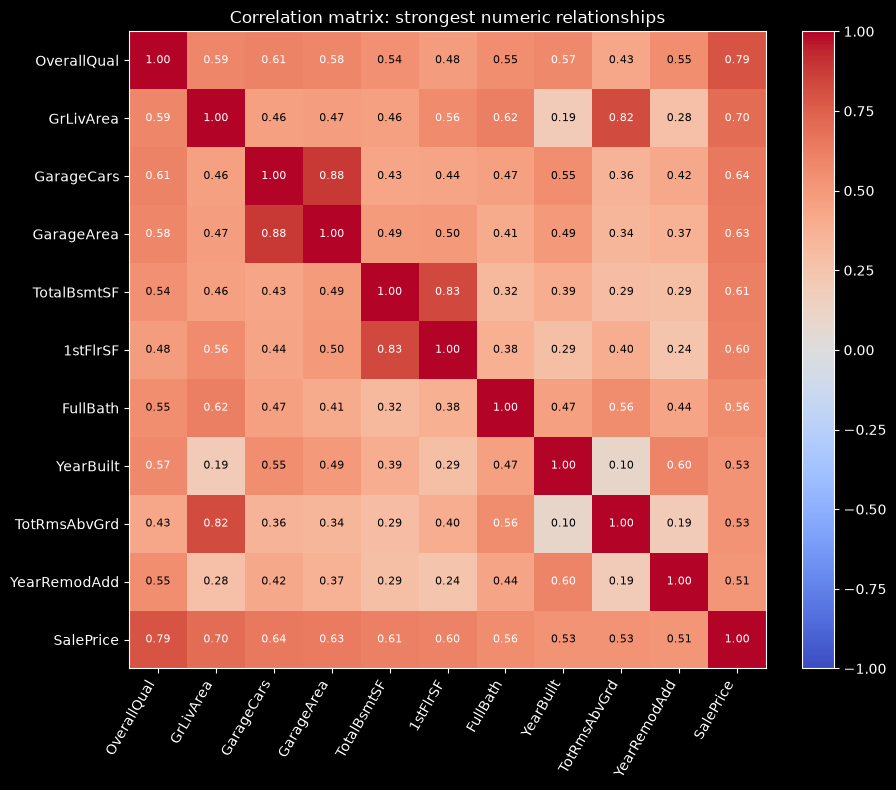

In [29]:
top_numeric = numeric_correlations.head(10).index.tolist()
heatmap_columns = top_numeric + ["SalePrice"]
corr_matrix = train[heatmap_columns].corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_columns)), heatmap_columns, rotation=60, ha="right")
ax.set_yticks(range(len(heatmap_columns)), heatmap_columns)

for row in range(len(heatmap_columns)):
    for column in range(len(heatmap_columns)):
        value = corr_matrix.iloc[row, column]
        text_color = "white" if abs(value) > 0.55 else "black"
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

ax.set_title("Correlation matrix: strongest numeric relationships")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "numeric_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

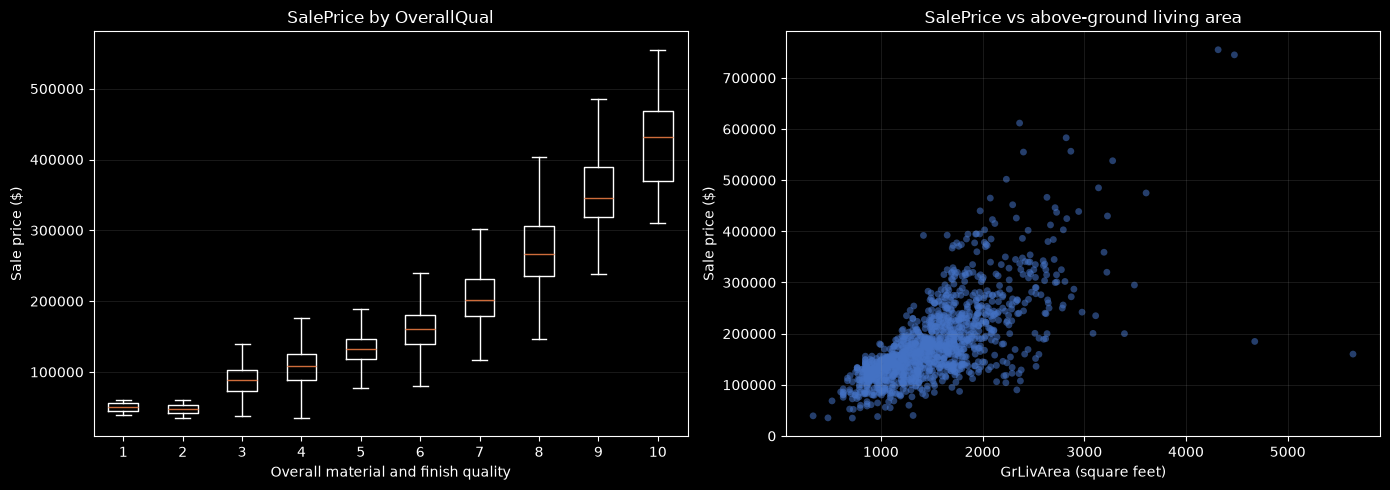

In [30]:
quality_levels = sorted(train["OverallQual"].unique())
price_by_quality = [
    train.loc[train["OverallQual"] == quality, "SalePrice"] for quality in quality_levels
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(price_by_quality, tick_labels=quality_levels, showfliers=False)
axes[0].set_title("SalePrice by OverallQual")
axes[0].set_xlabel("Overall material and finish quality")
axes[0].set_ylabel("Sale price ($)")
axes[0].grid(axis="y", alpha=0.2)

axes[1].scatter(
    train["GrLivArea"],
    train["SalePrice"],
    alpha=0.55,
    s=24,
    color="#4472C4",
    edgecolors="none",
)
axes[1].set_title("SalePrice vs above-ground living area")
axes[1].set_xlabel("GrLivArea (square feet)")
axes[1].set_ylabel("Sale price ($)")
axes[1].grid(alpha=0.2)

fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "key_price_relationships.png", dpi=160, bbox_inches="tight")
plt.show()

### 1.7 Neighborhood effect

Neighborhood has many categories and a visible relationship with price. It should be retained and one-hot encoded rather than replaced with arbitrary integer codes. The plot uses medians because they are less sensitive to a few very expensive houses.

,median_price,mean_price,house_count
Neighborhood,,,
NridgHt,"317,000.000","319,981.887",71
NoRidge,"302,000.000","333,488.121",33
StoneBr,"282,000.000","318,570.727",22
Timber,"228,000.000","241,752.171",35
Somerst,"226,850.000","228,259.789",76
Veenker,"218,000.000","238,772.727",11
Crawfor,"200,624.000","207,361.356",45
CollgCr,"200,070.500","199,930.471",140
ClearCr,"196,000.000","208,858.923",26


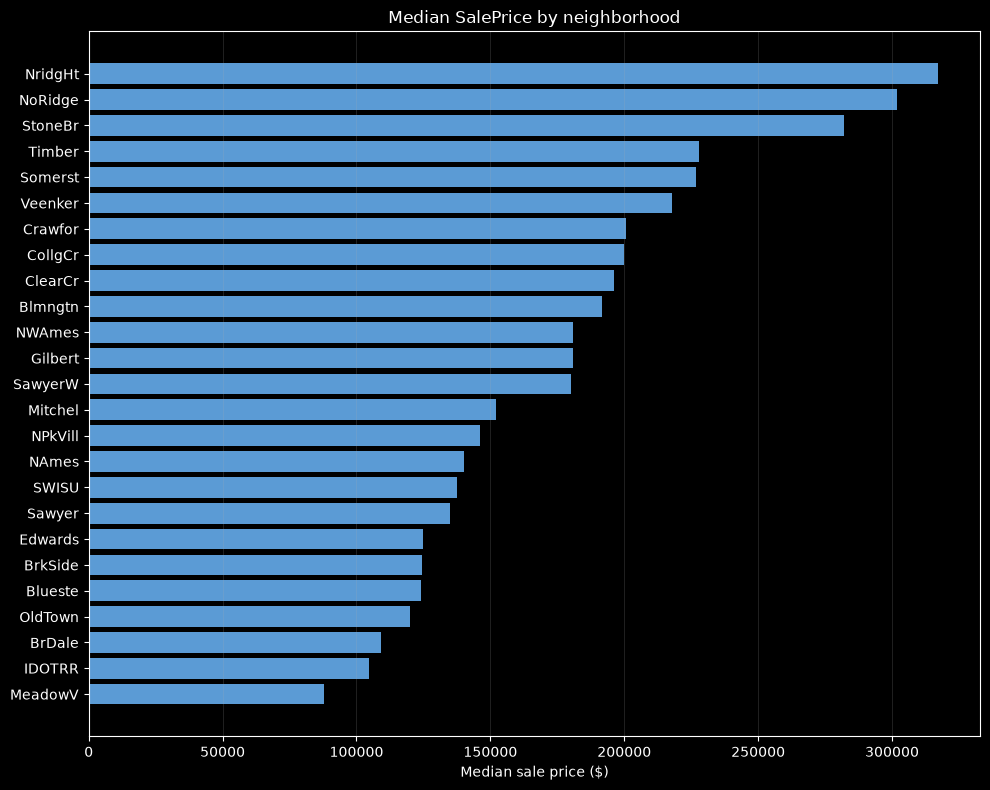

In [31]:
neighborhood_summary = (
    train.groupby("Neighborhood")["SalePrice"]
    .agg(median_price="median", mean_price="mean", house_count="size")
    .sort_values("median_price")
)
display(neighborhood_summary.sort_values("median_price", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(neighborhood_summary.index, neighborhood_summary["median_price"], color="#5B9BD5")
ax.set_title("Median SalePrice by neighborhood")
ax.set_xlabel("Median sale price ($)")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "neighborhood_median_prices.png", dpi=160, bbox_inches="tight")
plt.show()

neighborhood_summary.to_csv(ARTIFACT_DIR / "neighborhood_price_summary.csv")

### 1.8 Handoff to the preprocessing and modeling team

Verified findings:

- the training set has 1,314 rows and the final test set has 146 rows;
- both datasets have 81 columns, including `Id` and `SalePrice`;
- there are no duplicate rows, duplicate IDs, or overlapping IDs between the splits;
- after removing `Id` and `SalePrice`, there are 79 candidate predictors;
- the training target median is $162,950 and the mean is approximately $181,045;
- `SalePrice` is strongly right-skewed (skewness about 1.88);
- the strongest linear numeric associations include `OverallQual`, `GrLivArea`, garage capacity/area, basement area, and first-floor area;
- many missing categorical values describe structural absence, not corrupted data.

Preprocessing contract for the next teammate:

1. Preserve every test row and preserve `Id` separately for traceability.
2. Remove `Id` and `SalePrice` from `X`; quarantine test `SalePrice` until final evaluation.
3. Cast `MSSubClass` to categorical.
4. Fill structural-absence categorical fields with `"None"`.
5. Handle genuine numeric/categorical unknowns using imputers fitted inside the pipeline.
6. One-hot encode nominal categories with unknown-category handling enabled.
7. Compare models using the same validation folds and report at least MAE, RMSE, and R².
8. Consider a log-transformed target, but convert predictions back to dollars before reporting final MAE/RMSE.

No model has been selected in this section. That decision belongs to the validation results, not to EDA.

In [32]:
assert len(test) == original_test_row_count, "Test rows were accidentally removed."
print(f"Integrity check passed: all {original_test_row_count} test rows are still present.")
print(f"EDA artifacts saved to: {ARTIFACT_DIR.resolve()}")

Integrity check passed: all 146 test rows are still present.
EDA artifacts saved to: /home/nikalexan/Documents/Machine Learning/Midterm/eda_artifacts


## 2. Data preprocessing and model training

This section uses only `train.csv`. Filling structural-absence values with `"None"` or `0` does not learn anything from the data, so it happens before the split. Imputation, scaling and encoding do learn statistics, so they sit inside a `Pipeline` and are refit on each CV fold.

In [33]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42


def prepare_features(df):
    """Deterministic, row-wise cleaning from the EDA handoff. Learns nothing from data."""
    X = df.drop(columns=["Id", "SalePrice"]).copy()
    X["MSSubClass"] = X["MSSubClass"].astype(str)
    X[absence_means_none] = X[absence_means_none].fillna("None")
    X["MasVnrArea"] = X["MasVnrArea"].fillna(0)
    return X


train_ids = train["Id"].copy()
X = prepare_features(train)
y = train["SalePrice"].copy()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
assert "Id" not in X and "SalePrice" not in X
print(f"X: {X.shape}, numeric: {len(numeric_features)}, categorical: {len(categorical_features)}")

X: (1314, 79), numeric: 35, categorical: 44


In [34]:
preprocessor = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()),
     numeric_features),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
     categorical_features),
])


def make_model(estimator, log_target=False):
    if log_target:
        # Fit on log1p(price); predictions are inverse-transformed, so metrics stay in dollars.
        estimator = TransformedTargetRegressor(regressor=estimator, func=np.log1p, inverse_func=np.expm1)
    return Pipeline([("preprocess", preprocessor), ("model", estimator)])


models = {
    "Dummy (median)": make_model(DummyRegressor(strategy="median")),
    "Ridge": make_model(Ridge(alpha=10.0)),
    "Ridge (log1p target)": make_model(Ridge(alpha=10.0), log_target=True),
    "Random Forest": make_model(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    "Gradient Boosting": make_model(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    "Gradient Boosting (log1p target)": make_model(GradientBoostingRegressor(random_state=RANDOM_STATE), log_target=True),
}

In [35]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # same folds for every model
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}

rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    row = {"model": name}
    for metric in scoring:
        values = scores[f"test_{metric}"] * (-1 if metric != "R2" else 1)
        row[f"{metric}_mean"], row[f"{metric}_std"] = values.mean(), values.std()
    rows.append(row)

cv_results = pd.DataFrame(rows).set_index("model").sort_values("RMSE_mean")
cv_results.to_csv(ARTIFACT_DIR / "cv_results.csv")
display(cv_results.style.format({c: "{:,.0f}" for c in cv_results if not c.startswith("R2")} | {"R2_mean": "{:.3f}", "R2_std": "{:.3f}"}))

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
model,,,,,,
Gradient Boosting (log1p target),"16,559",922,"30,017","8,745",0.851,0.078
Gradient Boosting,"17,134","1,217","31,016","9,720",0.841,0.091
Random Forest,"18,377","1,054","32,325","8,370",0.830,0.077
Ridge,"18,318","1,250","33,227","12,057",0.815,0.125
Ridge (log1p target),"17,946","3,886","53,660","57,718",0.150,1.495
Dummy (median),"55,768","3,583","81,732","6,317",-0.056,0.032


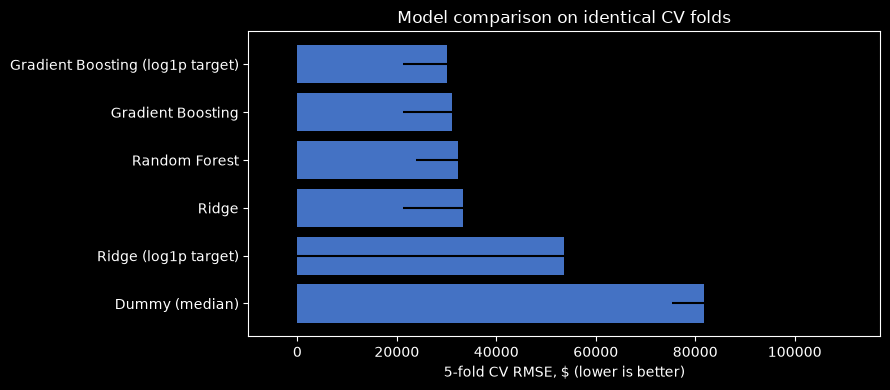

In [36]:
fig, ax = plt.subplots(figsize=(9, 4))
ordered = cv_results.sort_values("RMSE_mean", ascending=False)
ax.barh(ordered.index, ordered["RMSE_mean"], xerr=ordered["RMSE_std"], color="#4472C4")
ax.set_xlabel("5-fold CV RMSE, $ (lower is better)")
ax.set_title("Model comparison on identical CV folds")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "cv_rmse_comparison.png", dpi=150)
plt.show()

### 2.1 Handoff to the third team member

- `models`: dict of unfitted pipelines (preprocessing plus estimator). `X` and `y` come from `train.csv` through `prepare_features`.
- `cv`: the shared `KFold(5, shuffle=True, random_state=42)`. Reuse it for tuning.
- `cv_results` and `eda_artifacts/cv_results.csv`: MAE and RMSE in dollars plus R², mean and std over folds.
- `test.csv` is untouched. Once the model is frozen, run `prepare_features(test)` and the chosen pipeline on it once.
- Hyperparameters are defaults or simple fixed values. Tuning belongs to section 3 and uses train CV only.
- `Ridge (log1p target)` has a high RMSE because of one fold. In fold 0 the validation set contains Id 1299 (5,642 sq ft above ground, sold for $160,000, `SaleCondition = Partial`), and the model predicts about $2.77M for it. A linear model on log price extrapolates far outside the training range, and `expm1` turns that error exponential. Plain Ridge and the tree models do not blow up this way. On the other four folds its RMSE is $22–28k. Id 524 is a similar partial sale (4,676 sq ft, $184,750).

## 3. Model validation, comparison, and final test evaluation

The third team member audits the modeling handoff, freezes a model using training cross-validation, and evaluates it on the supplied holdout. **Mean 5-fold RMSE in dollars** is the selection criterion, chosen before opening test labels. MAE and R² provide complementary evidence. No additional tuning is needed for this small baseline comparison, and no decisions below depend on test performance.

### 3.1 Audit of the preprocessing and CV contract

`prepare_features` applies fixed row-wise rules only. Median imputation, scaling, most-frequent imputation and encoding live inside each pipeline. `cross_validate` clones the estimator for each fold, so the shared unfitted preprocessing prototype does not share learned statistics. Model fitting in section 2 uses only `X` and `y` from train.

All models receive the same deterministic `KFold(5, shuffle=True, random_state=42)` object in section 2. The checks below verify its partitions, feature exclusions, transformer configuration and unfitted prototypes. They document the implementation contract, rather than claiming that a generic assertion can prove the absence of every possible leakage source.

In [19]:
import hashlib
import json
import sklearn
from sklearn.base import clone
from sklearn.exceptions import NotFittedError
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.utils.validation import check_is_fitted

FINAL_ARTIFACT_DIR = Path("final_artifacts")
FINAL_ARTIFACT_DIR.mkdir(exist_ok=True)

pd.testing.assert_frame_equal(X, prepare_features(train))
pd.testing.assert_series_equal(y, train["SalePrice"])
assert X.shape == (len(train), 79)
assert "Id" not in X.columns and "SalePrice" not in X.columns
assert "MSSubClass" in categorical_features
assert set(numeric_features).isdisjoint(categorical_features)
assert set(numeric_features + categorical_features) == set(X.columns)
assert set(cv_results.index) == set(models)
assert np.isfinite(cv_results.to_numpy()).all()
assert cv.n_splits == 5 and cv.shuffle and cv.random_state == RANDOM_STATE

cv_splits = list(cv.split(X, y))
coverage = np.zeros(len(X), dtype=int)
fold_rows = []
for fold, (fit_positions, validation_positions) in enumerate(cv_splits):
    assert set(fit_positions).isdisjoint(validation_positions)
    assert len(fit_positions) + len(validation_positions) == len(X)
    coverage[validation_positions] += 1
    fold_rows.append({
        "fold": fold, "train_rows": len(fit_positions),
        "validation_rows": len(validation_positions),
        "validation_ids_sha256": hashlib.sha256(
            train_ids.iloc[validation_positions].to_numpy(dtype="int64").tobytes()
        ).hexdigest(),
    })
assert np.all(coverage == 1)
fold_audit = pd.DataFrame(fold_rows)
fold_audit.to_csv(FINAL_ARTIFACT_DIR / "cv_fold_audit.csv", index=False)

pipeline_rows = []
for name, candidate in models.items():
    assert list(candidate.named_steps) == ["preprocess", "model"]
    preprocessing = candidate.named_steps["preprocess"]
    parameters = preprocessing.get_params()
    assert parameters["num__simpleimputer__strategy"] == "median"
    assert parameters["num__simpleimputer__add_indicator"]
    assert parameters["cat__simpleimputer__strategy"] == "most_frequent"
    assert parameters["cat__onehotencoder__handle_unknown"] == "ignore"
    try:
        check_is_fitted(preprocessing)
    except NotFittedError:
        pass
    else:
        raise AssertionError(f"Unexpected fitted preprocessing prototype: {name}")
    pipeline_rows.append({"model": name, "preprocessing_inside_pipeline": True,
                          "unfitted_prototype": True, "shared_cv_folds": True})
pipeline_audit = pd.DataFrame(pipeline_rows)
pipeline_audit.to_csv(FINAL_ARTIFACT_DIR / "pipeline_audit.csv", index=False)
display(fold_audit)
display(pipeline_audit)

fold,train_rows,validation_rows,validation_ids_sha256
0,1051,263,04f29245e605d48df3e78123ca5df1c476e65d3701d5289c4371f463562f697b
1,1051,263,4c665be9877cd262d5c467f645dc38bbcc844ee9cf83870d232ba305e37965aa
2,1051,263,9f74ee18f37d945fae8aabfc7a9cdf3e5714daed9a2b40c669cd346891a80f7f
3,1051,263,3bffe37d0d8500dd4ecd2d88f48dbb7b1ee542b13942678f6487a609276eb45e
4,1052,262,53f1aca714e5976d531ed57131404e4eaa629088855399fe130dbe71fc2320ac


model,preprocessing_inside_pipeline,unfitted_prototype,shared_cv_folds
Dummy (median),True,True,True
Ridge,True,True,True
Ridge (log1p target),True,True,True
Random Forest,True,True,True
Gradient Boosting,True,True,True
Gradient Boosting (log1p target),True,True,True


### 3.2 Freeze the model using train/CV only

Select the smallest mean CV RMSE, using the model name as a deterministic tie-breaker. Keep the exact section 2 hyperparameters and clone the pipeline before fitting. The CV standard deviation describes variation across folds, not a confidence interval. The relatively small RMSE gap between the two boosting variants does not establish statistical superiority.

In [20]:
selection_table = cv_results.reset_index().sort_values(
    ["RMSE_mean", "model"], kind="stable"
).reset_index(drop=True)
selected_model_name = selection_table.loc[0, "model"]
final_model = clone(models[selected_model_name])
selection_table["selected"] = selection_table["model"].eq(selected_model_name)
selection_table.to_csv(FINAL_ARTIFACT_DIR / "model_comparison.csv", index=False)

selection_record = {
    "model": selected_model_name,
    "criterion": "Lowest mean 5-fold CV RMSE in dollars; name breaks exact ties",
    "cv": {"n_splits": cv.n_splits, "shuffle": cv.shuffle,
           "random_state": cv.random_state},
    "training_rows": len(X),
    "predictor_columns": X.columns.tolist(),
    "additional_tuning": False,
    "sklearn_version": sklearn.__version__,
    "selected_cv_metrics": cv_results.loc[selected_model_name].to_dict(),
    "model_parameters": {key: repr(value) for key, value in
                         final_model.named_steps["model"].get_params(deep=True).items()},
    "input_sha256": {name: hashlib.sha256(Path(name).read_bytes()).hexdigest()
                     for name in ["train.csv", "test.csv"]},
}
# Persist the frozen decision before fitting and before using test target values.
(FINAL_ARTIFACT_DIR / "model_selection.json").write_text(
    json.dumps(selection_record, indent=2), encoding="utf-8"
)
display(selection_table)
display(f"Frozen model: {selected_model_name}. No test metrics used for selection.")
final_model.fit(X, y)

Out[20]: 
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['LotFrontage', 'LotArea',
                                                   'OverallQual', 'OverallCond',
                                                   'YearBuilt', 'YearRemodAdd',
                                                   'MasVnrArea', 'BsmtFinSF1',
                                                   'BsmtFinSF2', 'BsmtUnfSF',
                                               

model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,selected
Gradient Boosting (log1p target),16558.602889,921.729655,30016.579549,8745.392796,0.851101,0.078486,True
Gradient Boosting,17126.072934,1187.701820,31027.069392,9553.728228,0.840903,0.089458,False
Random Forest,18376.849738,1053.625387,32324.852979,8369.881663,0.830405,0.076578,False
Ridge,18318.102409,1249.631208,33226.754263,12056.512888,0.814641,0.124543,False
Ridge (log1p target),17945.840429,3886.254543,53660.460134,57717.873004,0.150147,1.495007,False
Dummy (median),55768.010214,3582.716352,81732.486705,6316.997966,-0.055583,0.031842,False


'Frozen model: Gradient Boosting (log1p target). No test metrics used for selection.'

### 3.3 One final evaluation on all 146 test rows

Only the frozen model predicts the holdout. `TransformedTargetRegressor` converts log-target predictions back to dollars automatically. The residual convention is **actual minus predicted**, so a positive residual means underestimation. The table retains IDs and the original test row order. Re-running the notebook reproduces this same fixed procedure, without tuning against the holdout.

In [21]:
X_test_final = prepare_features(test)
assert len(X_test_final) == original_test_row_count == 146
assert X_test_final.index.equals(test.index)
assert X_test_final.columns.equals(X.columns)
assert set(train_ids).isdisjoint(test["Id"])
assert "SalePrice" not in X_test_final and "Id" not in X_test_final

test_predictions = final_model.predict(X_test_final)
assert test_predictions.shape == (original_test_row_count,)
assert np.isfinite(test_predictions).all()
# First use of test target values for model performance, after freezing and fitting.
y_test_final = test["SalePrice"].copy()
final_metrics = pd.DataFrame([{
    "model": selected_model_name,
    "test_rows": original_test_row_count,
    "MAE": mean_absolute_error(y_test_final, test_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test_final, test_predictions)),
    "R2": r2_score(y_test_final, test_predictions),
}])
final_metrics.to_csv(FINAL_ARTIFACT_DIR / "test_metrics.csv", index=False)

prediction_table = pd.DataFrame({
    "Id": test["Id"].to_numpy(),
    "actual_price": y_test_final.to_numpy(),
    "predicted_price": test_predictions,
})
prediction_table["residual"] = prediction_table["actual_price"] - prediction_table["predicted_price"]
prediction_table["absolute_error"] = prediction_table["residual"].abs()
assert len(prediction_table) == len(test) and prediction_table["Id"].is_unique
assert prediction_table["Id"].tolist() == test["Id"].tolist()
prediction_table.to_csv(FINAL_ARTIFACT_DIR / "test_predictions.csv", index=False)

display(final_metrics.style.format({"MAE": "${:,.0f}", "RMSE": "${:,.0f}", "R2": "{:.3f}"}))
display(prediction_table.head(10))

,model,test_rows,MAE,RMSE,R2
0,Gradient Boosting (log1p target),146,"$14,622","$20,118",0.929


Id,actual_price,predicted_price,residual,absolute_error
1227,214000,206295.240507,7704.759493,7704.759493
932,117500,123694.169905,-6194.169905,6194.169905
647,98300,101394.439599,-3094.439599,3094.439599
547,210000,171330.849677,38669.150323,38669.150323
812,144500,142339.978994,2160.021006,2160.021006
281,228500,235227.656818,-6727.656818,6727.656818
440,110000,141286.065497,-31286.065497,31286.065497
277,201000,212298.956669,-11298.956669,11298.956669
207,143900,132831.322992,11068.677008,11068.677008
761,127500,125461.306178,2038.693822,2038.693822


### 3.4 Prediction and error diagnostics

The diagonal in actual vs predicted represents perfect predictions. The residual histogram shows bias and the spread of errors. Residuals against predicted price help reveal uneven errors across the price range. These are descriptive checks of the frozen model, not a new round of test-based model selection.

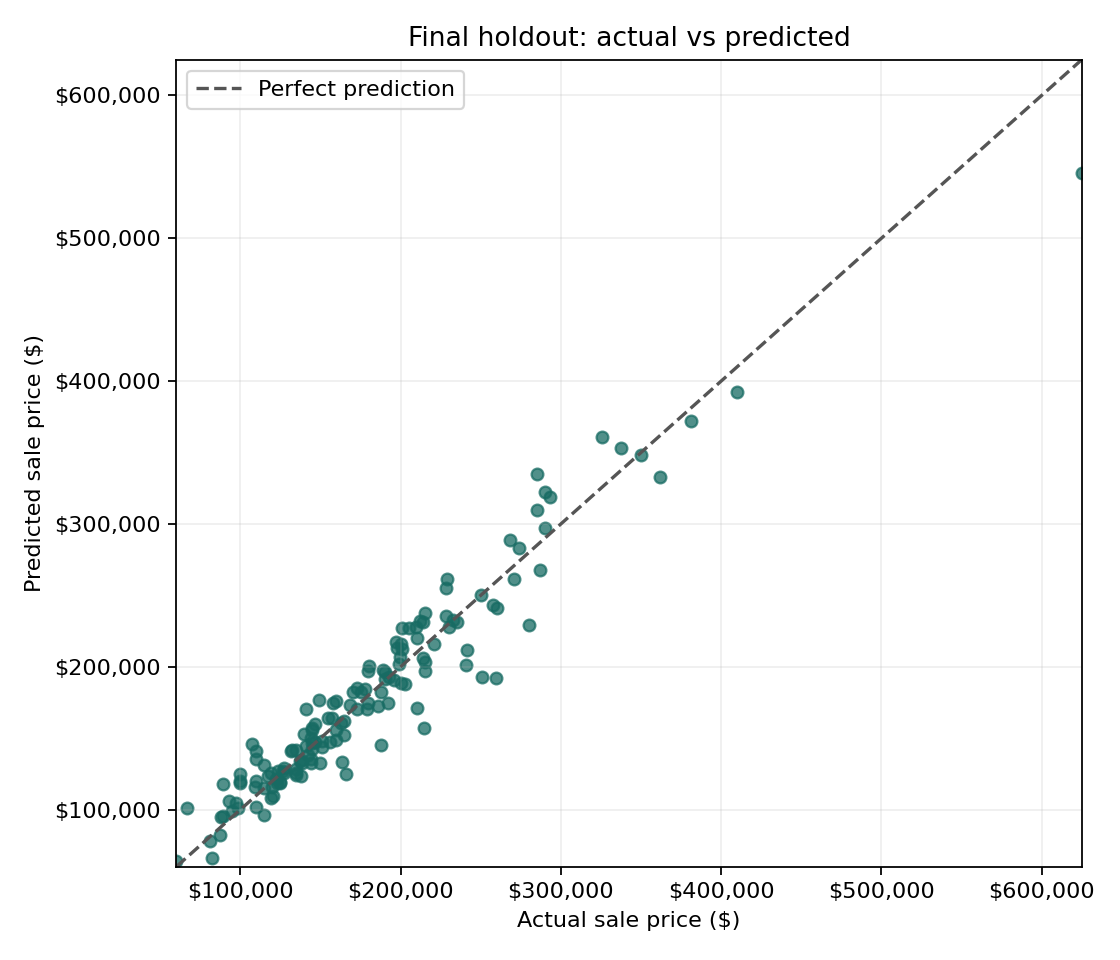

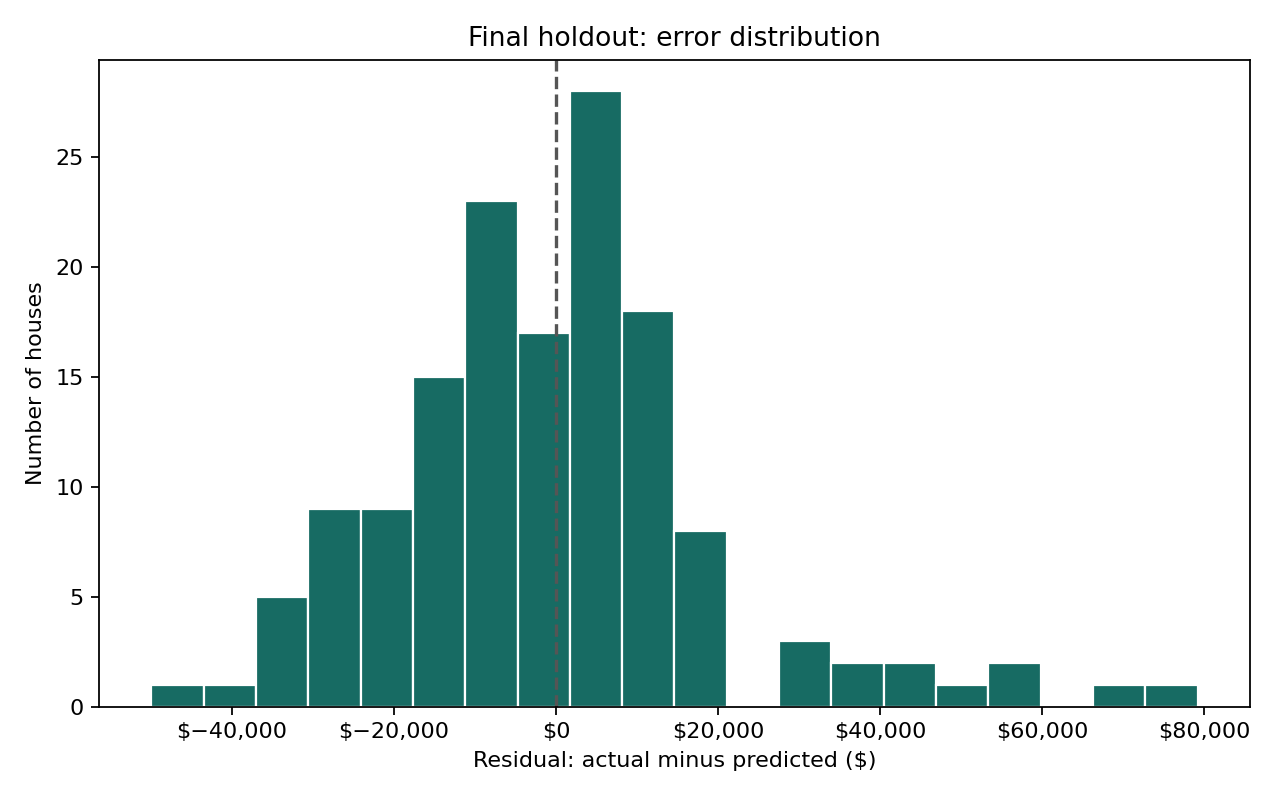

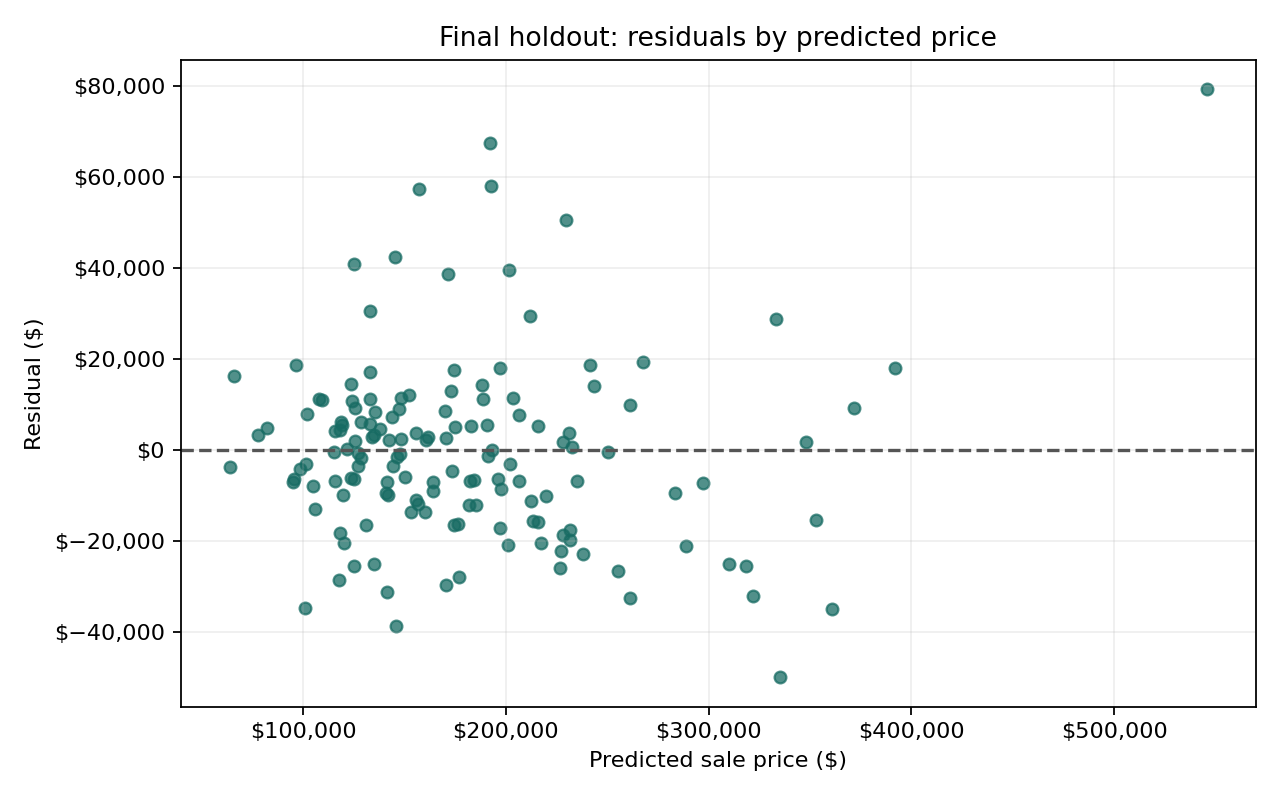

mean_residual,median_absolute_error,p90_absolute_error,max_absolute_error
-573.128205,10390.789529,31662.313844,79217.561464


Id,actual_price,predicted_price,residual,absolute_error
1170,625000,545782.438536,79217.561464,79217.561464
115,259500,192110.097785,67389.902215,67389.902215
865,250580,192644.801913,57935.198087,57935.198087
329,214500,157159.560412,57340.439588,57340.439588
452,280000,229572.117591,50427.882409,50427.882409


In [22]:
from matplotlib.ticker import StrMethodFormatter

money_formatter = StrMethodFormatter("${x:,.0f}")
actual = prediction_table["actual_price"]
predicted = prediction_table["predicted_price"]
residual = prediction_table["residual"]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(actual, predicted, color="#176B63", alpha=0.75, s=28)
limits = [min(actual.min(), predicted.min()), max(actual.max(), predicted.max())]
ax.plot(limits, limits, linestyle="--", color="#555555", label="Perfect prediction")
ax.set(xlabel="Actual sale price ($)", ylabel="Predicted sale price ($)",
       title="Final holdout: actual vs predicted", xlim=limits, ylim=limits)
ax.xaxis.set_major_formatter(money_formatter)
ax.yaxis.set_major_formatter(money_formatter)
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FINAL_ARTIFACT_DIR / "actual_vs_predicted.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residual, bins=20, color="#176B63", edgecolor="white")
ax.axvline(0, color="#555555", linestyle="--")
ax.set(xlabel="Residual: actual minus predicted ($)", ylabel="Number of houses",
       title="Final holdout: error distribution")
ax.xaxis.set_major_formatter(money_formatter)
fig.tight_layout()
fig.savefig(FINAL_ARTIFACT_DIR / "residual_distribution.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(predicted, residual, color="#176B63", alpha=0.75, s=28)
ax.axhline(0, color="#555555", linestyle="--")
ax.set(xlabel="Predicted sale price ($)", ylabel="Residual ($)",
       title="Final holdout: residuals by predicted price")
ax.xaxis.set_major_formatter(money_formatter)
ax.yaxis.set_major_formatter(money_formatter)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FINAL_ARTIFACT_DIR / "residuals_vs_predicted.png", dpi=160)
plt.show()

error_summary = pd.DataFrame([{
    "mean_residual": residual.mean(),
    "median_absolute_error": prediction_table["absolute_error"].median(),
    "p90_absolute_error": prediction_table["absolute_error"].quantile(0.90),
    "max_absolute_error": prediction_table["absolute_error"].max(),
}])
error_summary.to_csv(FINAL_ARTIFACT_DIR / "error_summary.csv", index=False)
display(error_summary)
display(prediction_table.nlargest(5, "absolute_error"))

### 3.5 Findings, limitations, and presentation handoff

Interpret errors in dollars. R² measures improvement over the holdout mean-price reference and is not a classification accuracy or a percentage of correctly priced houses. A small holdout and unusually expensive or atypical properties can materially change RMSE. KFold measures performance under a random split, rather than a future-time or new-city deployment.

The Ridge log-target failure observed in CV is a reminder that inverse exponentiation can magnify extrapolation errors. We retain all houses and report that limitation rather than deleting difficult cases. Further experiments should use training CV or a new validation set, while preserving this holdout as a final assessment.

In [23]:
test_result = final_metrics.iloc[0]
cv_result = cv_results.loc[selected_model_name]
baseline_rmse = cv_results.loc["Dummy (median)", "RMSE_mean"]
cv_improvement_pct = 100 * (1 - cv_result["RMSE_mean"] / baseline_rmse)
summary = f"""# Final evaluation handoff

Selected model: {selected_model_name}.
Selection: lowest mean training 5-fold CV RMSE, fixed KFold seed 42, no extra tuning.

## Results
- CV MAE: ${cv_result['MAE_mean']:,.0f} (fold SD ${cv_result['MAE_std']:,.0f}).
- CV RMSE: ${cv_result['RMSE_mean']:,.0f} (fold SD ${cv_result['RMSE_std']:,.0f}).
- CV R²: {cv_result['R2_mean']:.3f}.
- CV RMSE reduction vs the median baseline: {cv_improvement_pct:.1f}%.
- Final test: {original_test_row_count} houses, all rows preserved.
- Test MAE: ${test_result['MAE']:,.0f}.
- Test RMSE: ${test_result['RMSE']:,.0f}.
- Test R²: {test_result['R2']:.3f}.
- Mean residual (actual minus predicted): ${residual.mean():,.0f}.
- 90th percentile absolute error: ${prediction_table['absolute_error'].quantile(.90):,.0f}.

## Interpretation and limitations
The test metrics describe a single supplied holdout. CV and test contain different houses,
so their difference is not a paired comparison. Fold SD is not a confidence interval.
The small CV gap between boosting variants does not prove statistical superiority.
R² is not accuracy. Errors can be much larger for individual houses than the mean error.
Random folds do not establish performance in a different city or future market.
No test result was used to choose or retune the model.

## Presentation sources
Use EDA_HANDOFF.md and eda_artifacts for data and EDA, model_comparison.csv for CV,
test_metrics.csv for final results, and test_predictions.csv for editable diagnostic charts.
The PPTX is delivered separately and is not a repository artifact.
"""
Path("FINAL_HANDOFF.md").write_text(summary, encoding="utf-8")
display(summary)
assert len(test) == original_test_row_count
for name, expected_hash in selection_record["input_sha256"].items():
    assert hashlib.sha256(Path(name).read_bytes()).hexdigest() == expected_hash

'# Final evaluation handoff\n\nSelected model: Gradient Boosting (log1p target).\nSelection: lowest mean training 5-fold CV RMSE, fixed KFold seed 42, no extra tuning.\n\n## Results\n- CV MAE: $16,559 (fold SD $922).\n- CV RMSE: $30,017 (fold SD $8,745).\n- CV R²: 0.851.\n- CV RMSE reduction vs the median baseline: 63.3%.\n- Final test: 146 houses, all rows preserved.\n- Test MAE: $14,622.\n- Test RMSE: $20,118.\n- Test R²: 0.929.\n- Mean residual (actual minus predicted): $-573.\n- 90th percentile absolute error: $31,662.\n\n## Interpretation and limitations\nThe test metrics describe a single supplied holdout. CV and test contain different houses,\nso their difference is not a paired comparison. Fold SD is not a confidence interval.\nThe small CV gap between boosting variants does not prove statistical superiority.\nR² is not accuracy. Errors can be much larger for individual houses than the mean error.\nRandom folds do not establish performance in a different city or future market.\